In [4]:
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error
import mne
import asrpy
import warnings
from sklearn.exceptions import ConvergenceWarning

In [11]:
#Helper Functions
def norm_freq(f, fs): return f * 2 / fs

def filter(data, fs):
    b_notch, a_notch = scipy.signal.iirnotch(50, Q=30, fs=fs)
    wn = (norm_freq(2, fs), norm_freq(60, fs))
    sos_band = scipy.signal.butter(N=4, Wn=wn, btype='bandpass', output='sos')
    filtered = np.zeros_like(data)
    for ch in range(data.shape[1]):
        x = data[:, ch]
        x_notched = scipy.signal.lfilter(b_notch, a_notch, x)
        x_filtered = scipy.signal.sosfilt(sos_band, x_notched)
        filtered[:, ch] = x_filtered
    return filtered

def ASR(data, fs):
    data_T = data.T 
    info = mne.create_info(ch_names=[f"ch{i}" for i in range(data_T.shape[0])], sfreq=fs, ch_types="eeg")
    raw_T = mne.io.RawArray(data_T, info, verbose=False)
    asr = asrpy.ASR(sfreq=fs, cutoff=20.0)  
    asr.fit(raw_T)  
    return asr.transform(raw_T).get_data().T

def extract_features_from_window(window, fs):
    features = []
    #Frequency Domain
    # Define only Theta (4-8), Alpha (8-12), and Beta (12-40) bands (using only these feaatures yielded the best results)
    bands = [(4, 8), (8, 12), (12, 40)]
    
    for ch in range(window.shape[1]):
        signal = window[:, ch]
        
        # Calculate FFT
        fft_vals = np.abs(np.fft.fft(signal)[:len(signal)//2])**2
        freqs = np.fft.fftfreq(len(signal), 1/fs)[:len(signal)//2]
        
        # Extract power for each specific band
        for band in bands:
            mask = (freqs >= band[0]) & (freqs <= band[1])
            features.append(np.sum(fft_vals[mask]))
            
    return np.array(features)

def build_dataset(all_data, fs, window_size, step_size):
    X, y = [], []
    print(f"Building dataset from {len(all_data)} files...")
    for d in all_data:
        data_trig = d[:, -1]
        data = ASR(filter(d[:, 0:8], fs), fs)
        start = 0
        while start + window_size <= data.shape[0]:
            X.append(extract_features_from_window(data[start:start+window_size], fs))
            y.append(data_trig[start:start+window_size].mean()) # Use mean label for regression
            start += step_size
    return np.array(X), np.array(y)

def train_model(X, y, max_iter=300):

    #supress max_iter=1 convergence warnings
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    
    print("Training MLPRegressor...")
    mlp = MLPRegressor(hidden_layer_sizes=(64, 32), activation="relu", solver="adam", max_iter=1, warm_start=True)

    losses, train_r2_scores, test_r2_scores = [], [], []
    for i in range(max_iter):
        mlp.fit(X_train, y_train)
        losses.append(mlp.loss_)
        train_r2_scores.append(mlp.score(X_train, y_train))
        test_r2_scores.append(mlp.score(X_test, y_test))

    print(f"Training Complete.")

    #calculate scores
    y_pred = mlp.predict(X_test)
    print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")
    print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")

    # Visualization
    fig, ax1 = plt.subplots(figsize=(8,5))
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Training Loss', color='tab:blue')
    line1 = ax1.plot(range(1, max_iter+1), losses, color='tab:blue', label='Training Loss')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True)
    
    ax2 = ax1.twinx() 
    ax2.set_ylabel('R² Score', color='tab:red')
    line2 = ax2.plot(range(1, max_iter+1), train_r2_scores, color='tab:red', linestyle='--', alpha=0.5, label='Training R²')
    line3 = ax2.plot(range(1, max_iter+1), test_r2_scores, color='tab:red', linewidth=2, label='Test R²')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right')
    
    plt.title('MLPRegressor Training Loss and R² Scores over Iterations')
    plt.show()

    return mlp, scaler


def analyze_focus(filename, mlp, scaler, fs=500, step_sec=0.05, smooth_sec=5):
    print(f"--- Analyzing: {filename} ---")
    try:
        raw = np.genfromtxt(filename, delimiter=',')[1:, 0:8]
    except: return print("Error loading file.")
    
    data = ASR(filter(raw, fs), fs)
    win_size, step = int(1*fs), int(step_sec*fs)
    
    feats, times = [], []
    for i in range((data.shape[0] - win_size) // step):
        s = i * step
        feats.append(extract_features_from_window(data[s:s+win_size], fs))
        times.append((s+win_size)/fs)
        if i % 200 == 0: print(".", end="", flush=True)
    print(" Done.")
    
    if len(feats) == 0: return
    
    # Continuous Predictions
    raw_scores = mlp.predict(scaler.transform(feats)) * 100
    
    # Smoothing
    k_size = int(smooth_sec / step_sec)
    smoothed = np.convolve(raw_scores, np.ones(k_size)/k_size, mode='same')
    smoothed[:k_size//2] = np.nan; smoothed[-k_size//2:] = np.nan
    
    # Plot
    plt.figure(figsize=(12, 6))
    
    # 1. Plot raw and smoothed lines with updated labels
    plt.plot(times, raw_scores, color='lightgray', alpha=0.5, label=f'Raw ({step_sec}s step)')
    plt.plot(times, smoothed, color='darkblue', linewidth=2, label=f'Trend ({smooth_sec}s average)')
    
    # 2. Add horizontal lines for threshold and baseline
    plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='Threshold (50%)')
    plt.axhline(100, color='green', linestyle='--', alpha=0.5, label='Training Baseline 100%')
    
    # 3. Fill area under the trend line
    plt.fill_between(times, 0, smoothed, color='blue', alpha=0.1, where=~np.isnan(smoothed))
    
    # 4. Formatting and Labels
    plt.ylabel('Focus level [%]')
    plt.xlabel('Time [s]')
    plt.ylim(bottom=-5) # Allows the top to auto-scale for unclipped scores
    plt.legend(loc='lower right')
    plt.title(f"Focus Analysis: {filename}")
    plt.show()

Building dataset from 10 files...
Training MLPRegressor...
Training Complete.
R2 Score: 0.94
MSE: 0.01


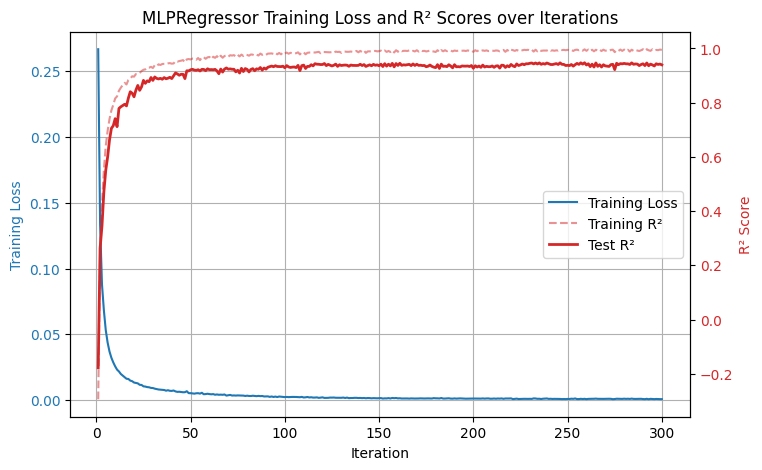

Model Trained Successfully!


In [13]:
# --- 2. Data Loading & Training (Run Once) ---
try:
    # Load Training Data
    f1 = np.genfromtxt('eeg_data/focus1.csv', delimiter=',')[1:]; f1[:,-1]=1
    f2 = np.genfromtxt('eeg_data/focus2.csv', delimiter=',')[1:]; f2[:,-1]=1
    f3 = np.genfromtxt('eeg_data/focus3.csv', delimiter=',')[1:]; f3[:,-1]=1
    f4 = np.genfromtxt('eeg_data/focus4.csv', delimiter=',')[1:]; f4[:,-1]=1
    f5 = np.genfromtxt('eeg_data/focus5.csv', delimiter=',')[1:]; f5[:,-1]=1
    
    r1 = np.genfromtxt('eeg_data/relax1.csv', delimiter=',')[1:]; r1[:,-1]=0
    r2 = np.genfromtxt('eeg_data/relax2.csv', delimiter=',')[1:]; r2[:,-1]=0
    r3 = np.genfromtxt('eeg_data/relax3.csv', delimiter=',')[1:]; r3[:,-1]=0
    r4 = np.genfromtxt('eeg_data/relax4.csv', delimiter=',')[1:]; r4[:,-1]=0
    r5 = np.genfromtxt('eeg_data/relax5.csv', delimiter=',')[1:]; r5[:,-1]=0
    
    all_data = [f1, f2, f3, f4, f5, r1, r2, r3, r4, r5]
    
    # Build & Train
    X_train, y_train = build_dataset(all_data, 500, int(1*500), int(0.9*500))
    mlp_model, scaler = train_model(X_train, y_train)
    print("Model Trained Successfully!")
    
except Exception as e:
    print(f"Training failed: {e}")

--- Analyzing: eeg_data/chess.csv ---
........ Done.


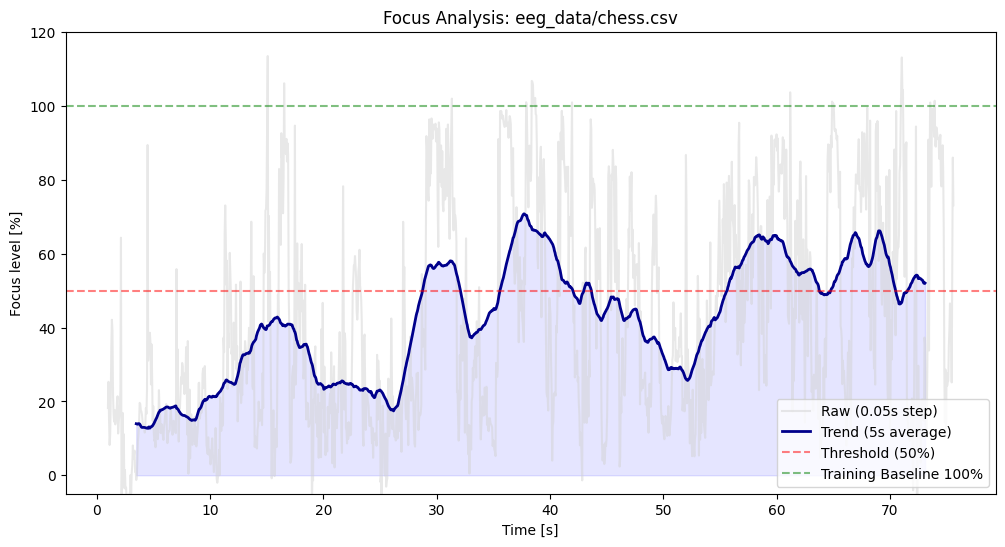

--- Analyzing: eeg_data/tetris1.csv ---
.................... Done.


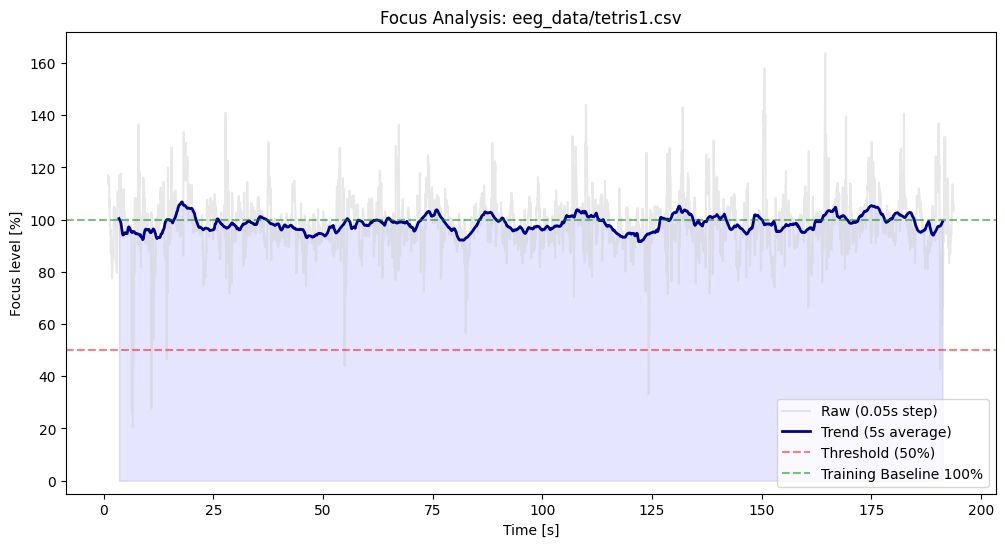

In [15]:
# Plot mental effort during games (Chess and Tetris)
game_files = [
    'eeg_data/chess.csv',
    'eeg_data/tetris1.csv',
]

for game in game_files:
    analyze_focus(
        filename=game, 
        mlp=mlp_model, 
        scaler=scaler, 
        fs=500, 
        step_sec=0.05, 
        smooth_sec=5
    )